In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyspark.sql.functions as f
import statsmodels.api as sm
from gentropy.common.session import Session


Loading BokehJS ...

/Users/dc16/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "10g"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/04 10:56:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/04 10:56:55 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
release_path = "../../../data/25.06/output/"
output_path = "../../../data/intermediate_files/"


In [4]:
target = session.spark.read.parquet(f"{release_path}/target")
studies = session.spark.read.parquet(f"{output_path}/gwas_w_therapeutic_areas").filter(
    ~f.col("measurement") & f.col("binaryLessCases")
)
variants = session.spark.read.parquet(f"{release_path}/variant")
qualified_studies = session.spark.read.parquet(f"{output_path}/qualifying_gwas_studies")
qualified_cs = session.spark.read.parquet(f"{output_path}/qualifying_credible_sets")
replicated_cs = session.spark.read.parquet(f"{output_path}/list_of_gwas_replicated_CSs.parquet")
l2g = session.spark.read.parquet(f"{output_path}/list_of_prioritised_genes_per_CS.parquet").select(
    "studyLocusId", "geneId"
)


In [5]:
cred_sets = (
    qualified_cs.join(
        l2g.groupBy("studyLocusId").agg(f.collect_list("geneId").alias("prioritisedGenes")),
        "studyLocusId",
        "left",
    )
    .join(
        studies.select(
            "studyId",
            "mappedTherapeuticAreas",
            "cancerOrBenignTumor",
            "infectiousDisease",
            "pregnancyOrPerinatalDisease",
            "disorderOfVisualSystem",
            "cardiovascularDisease",
            "pancreasDisease",
            "gastrointestinalDisease",
            "reproductiveSystemOrBreastDisease",
            "integumentarySystemDisease",
            "endocrineSystemDisease",
            "respiratoryOrThoracicDisease",
            "urinarySystemDisease",
            "musculoskeletalOrConnectiveTissueDisease",
            "disorderOfEar",
            "immuneSystemDisease",
            "hematologicDisease",
            "nervousSystemDisease",
            "psychiatricDisorder",
            "nutritionalOrMetabolicDisease",
            "geneticFamilialOrCongenitalDisease",
            "injuryPoisoningOrOtherComplication",
            "signOrSymptom",
            "other",
            "totalTherapeuticAreas",
            "publicationDate",
        ),
        "studyId",
        "inner",
    )
    .withColumn(
        "publicationDate",
        f.when(f.col("studyId").startswith("FINNGEN"), "2023-01-18").otherwise(f.col("publicationDate")),
    )
    .withColumn(
        "effectiveSampleSize",
        (f.lit(4.0) * f.col("nCases") * f.col("nControls")) / (f.col("nCases") + f.col("nControls")),
    )
    .withColumn(
        "coefficientDetermination",
        f.col("variantStatistics.chi2Stat") / f.col("effectiveSampleSize"),
    )
    # .join(replicated_cs, "studyLocusId", "semi")
)


In [6]:
print("Number of unique variantIds:", cred_sets.select("variantId").distinct().count())


Number of unique variantIds: 40706


In [7]:
print("Number of unique study IDs:", cred_sets.select("studyId").distinct().count())


Number of unique study IDs: 5438


In [8]:
variant_pleiotropy = (
    cred_sets.groupBy("variantId")
    .agg(
        f.mean(
            f.when(f.col("majorLdPopulation.ldPopulation") == "nfe", 1).otherwise(0),
        ).alias("nonEURProportion"),
        f.min(f.abs("rescaledStatistics.minorAlleleEstimatedBeta")).alias("minAbsBeta"),
        f.max(f.abs("rescaledStatistics.minorAlleleEstimatedBeta")).alias("maxAbsBeta"),
        f.min(f.col("coefficientDetermination")).alias("minCoefficientDetermination"),
        f.max(f.col("coefficientDetermination")).alias("maxCoefficientDetermination"),
        f.min(f.col("effectiveSampleSize")).alias("minEffectiveSampleSize"),
        f.max(f.col("effectiveSampleSize")).alias("maxEffectiveSampleSize"),
        f.min(f.col("rescaledStatistics.varG")).alias("minVarG"),
        f.max(f.col("rescaledStatistics.varG")).alias("maxVarG"),
        f.max(f.col("majorLdPopulationMaf.value")).alias("maxMAF"),
        f.avg(
            f.when(
                f.col("originalBeta").isNotNull(),
                f.signum(f.col("rescaledStatistics.minorAlleleEstimatedBeta")),
            )
        ).alias("averageBetaSign"),
        f.stddev_pop(
            f.when(
                f.col("originalBeta").isNotNull(),
                f.signum(f.col("rescaledStatistics.minorAlleleEstimatedBeta")),
            )
        ).alias("stdBetaSign"),
        f.greatest(
            f.sum(
                f.when(
                    (f.col("originalBeta").isNotNull()) & (f.col("rescaledStatistics.minorAlleleEstimatedBeta") > 0),
                    1.0,
                ).otherwise(0.0)
            )
            / f.sum(f.when(f.col("originalBeta").isNotNull(), 1.0).otherwise(0.0)),
            f.sum(
                f.when(
                    (f.col("originalBeta").isNotNull()) & (f.col("rescaledStatistics.minorAlleleEstimatedBeta") < 0),
                    1.0,
                ).otherwise(0.0)
            )
            / f.sum(f.when(f.col("originalBeta").isNotNull(), 1.0).otherwise(0.0)),
        ).alias("betaSignConcordance"),
        f.min("publicationDate").alias("earliestPublicationDate"),
        f.size(f.array_distinct(f.flatten(f.collect_list("diseaseIds")))).alias("uniqueDiseases"),
        f.size(f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas")))).alias("uniqueTherapeuticAreas"),
        f.sum("cancerOrBenignTumor").alias("cancerOrBenignTumor"),
        f.sum("infectiousDisease").alias("infectiousDisease"),
        f.sum("pregnancyOrPerinatalDisease").alias("pregnancyOrPerinatalDisease"),
        f.sum("disorderOfVisualSystem").alias("disorderOfVisualSystem"),
        f.sum("cardiovascularDisease").alias("cardiovascularDisease"),
        f.sum("pancreasDisease").alias("pancreasDisease"),
        f.sum("gastrointestinalDisease").alias("gastrointestinalDisease"),
        f.sum("reproductiveSystemOrBreastDisease").alias("reproductiveSystemOrBreastDisease"),
        f.sum("integumentarySystemDisease").alias("integumentarySystemDisease"),
        f.sum("endocrineSystemDisease").alias("endocrineSystemDisease"),
        f.sum("respiratoryOrThoracicDisease").alias("respiratoryOrThoracicDisease"),
        f.sum("urinarySystemDisease").alias("urinarySystemDisease"),
        f.sum("musculoskeletalOrConnectiveTissueDisease").alias("musculoskeletalOrConnectiveTissueDisease"),
        f.sum("disorderOfEar").alias("disorderOfEar"),
        f.sum("immuneSystemDisease").alias("immuneSystemDisease"),
        f.sum("hematologicDisease").alias("hematologicDisease"),
        f.sum("nervousSystemDisease").alias("nervousSystemDisease"),
        f.sum("psychiatricDisorder").alias("psychiatricDisorder"),
        f.sum("nutritionalOrMetabolicDisease").alias("nutritionalOrMetabolicDisease"),
        f.sum("geneticFamilialOrCongenitalDisease").alias("geneticFamilialOrCongenitalDisease"),
        f.sum("injuryPoisoningOrOtherComplication").alias("injuryPoisoningOrOtherComplication"),
        f.sum("signOrSymptom").alias("signOrSymptom"),
        f.sum("other").alias("other"),
        f.array_distinct(f.flatten(f.collect_list("diseaseIds"))).alias("uniqueDiseaseNames"),
        f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas"))).alias("uniqueTherapeuticAreaNames"),
        f.array_distinct(f.flatten(f.collect_list("prioritisedGenes"))).alias("prioritisedGenes"),
        f.countDistinct("studyId").alias("totalStudies"),
    )
    .join(
        variants.select("variantId", "variantEffect")
        .withColumns(
            {
                "gerpNormalised": f.filter(f.col("variantEffect"), lambda x: x["method"] == "GERP")[0][
                    "normalisedScore"
                ],
                "vepScore": f.filter(f.col("variantEffect"), lambda x: x["method"] == "VEP")[0]["score"],
            }
        )
        .drop("variantEffect"),
        "variantId",
        "left",
    )
    .sort(f.desc("uniqueTherapeuticAreas"), f.desc("uniqueDiseases"))
).cache()


26/02/04 10:57:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [9]:
variant_pleiotropy.write.parquet(
    f"{output_path}/variants_pleiotropy",
    mode="overwrite",
)


In [10]:
variant_pd = variant_pleiotropy.toPandas()
variant_pd


,variantId,nonEURProportion,minAbsBeta,maxAbsBeta,minCoefficientDetermination,maxCoefficientDetermination,minEffectiveSampleSize,maxEffectiveSampleSize,minVarG,maxVarG,...,geneticFamilialOrCongenitalDisease,injuryPoisoningOrOtherComplication,signOrSymptom,other,uniqueDiseaseNames,uniqueTherapeuticAreaNames,prioritisedGenes,totalStudies,gerpNormalised,vepScore
0,19_44908684_T_C,0.654450,0.020854,1.335100,0.000028,0.138225,613.779310,1.778690e+06,0.176526,0.343718,...,0,1,3,32,"[MONDO_0021187, EFO_0009267, EFO_0005774, EFO_...","[OTAR_0000020, EFO_0000618, MONDO_0024458, oth...",[ENSG00000130203],191,0.847500,0.66
1,10_112998590_C_T,0.720280,0.022714,1.974045,0.000053,0.096528,1375.764535,1.424218e+06,0.052306,0.414420,...,0,0,0,19,"[MONDO_0005148, EFO_0004265, EFO_0000400, EFO_...","[EFO_0009605, EFO_0000319, MONDO_0024458, othe...",[ENSG00000148737],143,0.351500,0.10
2,4_102267552_C_T,0.976471,0.040858,0.592906,0.000046,0.001467,34004.864451,1.990919e+06,0.000624,0.136789,...,0,2,3,10,"[MONDO_0005090, MONDO_0005178, MONDO_0004979, ...","[EFO_0000618, OTAR_0000006, OTAR_0000010, OTAR...",[ENSG00000138821],85,NaN,0.66
3,16_53767042_T_C,0.807018,0.026013,0.460475,0.000082,0.044235,2795.536481,7.655914e+05,0.260520,0.488089,...,0,0,0,4,"[EFO_0004616, EFO_0001073, MONDO_0005148, EFO_...","[OTAR_0000006, OTAR_0000020, EFO_0009605, OTAR...",[ENSG00000140718],57,0.983750,0.10
4,2_27508073_T_C,0.680412,0.033694,0.457093,0.000136,0.025111,1335.448193,1.424218e+06,0.239699,0.498391,...,0,0,0,10,"[EFO_0004274, MONDO_0024647, MONDO_0001336, EF...","[OTAR_0000006, EFO_0009690, OTAR_0000020, EFO_...",[ENSG00000084734],97,0.118333,0.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40701,X_154717327_G_A,1.000000,0.135947,0.135947,0.002027,0.002027,16417.447914,1.641745e+04,0.438665,0.438665,...,0,0,0,0,[MONDO_0005147],[EFO_0009605],[ENSG00000160219],1,0.043333,0.10
40702,X_51467205_C_T,1.000000,NaN,NaN,0.010798,0.010798,3747.573106,3.747573e+03,0.460302,0.460302,...,0,0,0,0,[EFO_0001663],[MONDO_0045024],[ENSG00000196368],1,0.520000,0.00
40703,X_6132847_C_T,1.000000,0.019209,0.019209,0.000046,0.000046,727796.366842,7.277964e+05,0.495659,0.495659,...,0,0,0,0,[EFO_0004698],[EFO_0000618],[ENSG00000146938],1,0.000000,0.10
40704,X_86737607_C_G,0.000000,0.061120,0.061120,0.000419,0.000419,72098.801462,7.209880e+04,0.448800,0.448800,...,0,0,0,0,[MONDO_0008315],[MONDO_0045024],[ENSG00000126733],1,0.130833,0.10


In [11]:
print(variant_pd["uniqueDiseases"].corr(variant_pd["uniqueTherapeuticAreas"]))


0.7635021976211611


In [12]:
variant_pd["gerpNormalised"] = variant_pd["gerpNormalised"].fillna(variant_pd["gerpNormalised"].mean())


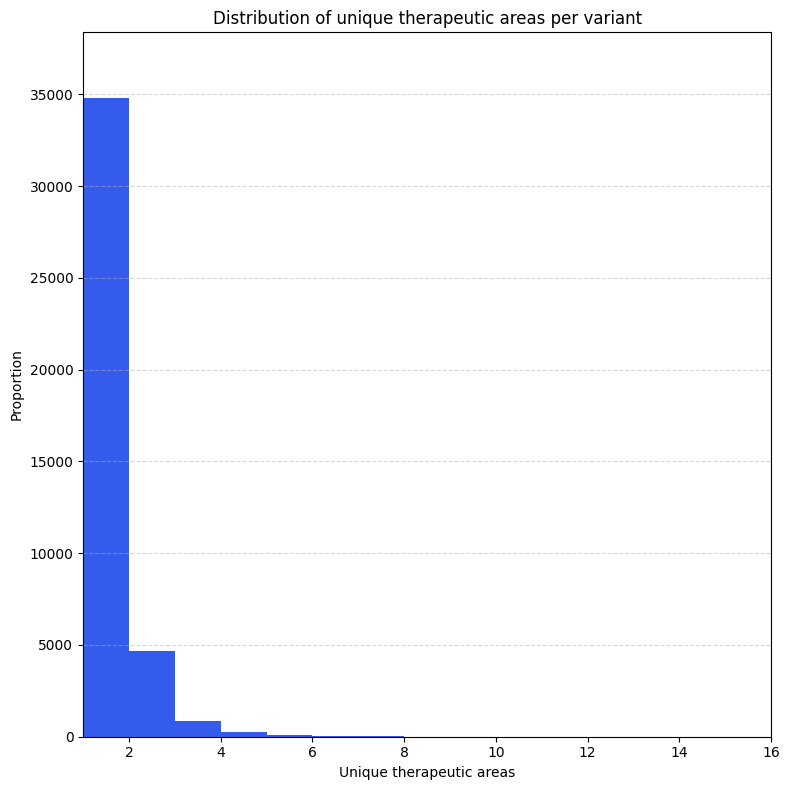

In [13]:
plt.figure(figsize=(8, 8))
n, bins, patches = plt.hist(
    variant_pd["uniqueTherapeuticAreas"],
    bins=range(
        int(variant_pd["uniqueTherapeuticAreas"].min()),
        int(variant_pd["uniqueTherapeuticAreas"].max()) + 2,
    ),
    color="#345BEB",
)
plt.title("Distribution of unique therapeutic areas per variant")
plt.xlabel("Unique therapeutic areas")
plt.ylabel("Proportion")
plt.gca().set_ylim(0, plt.gca().get_ylim()[1] * 1.05)
plt.gca().set_xlim(bins[0], bins[-1])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


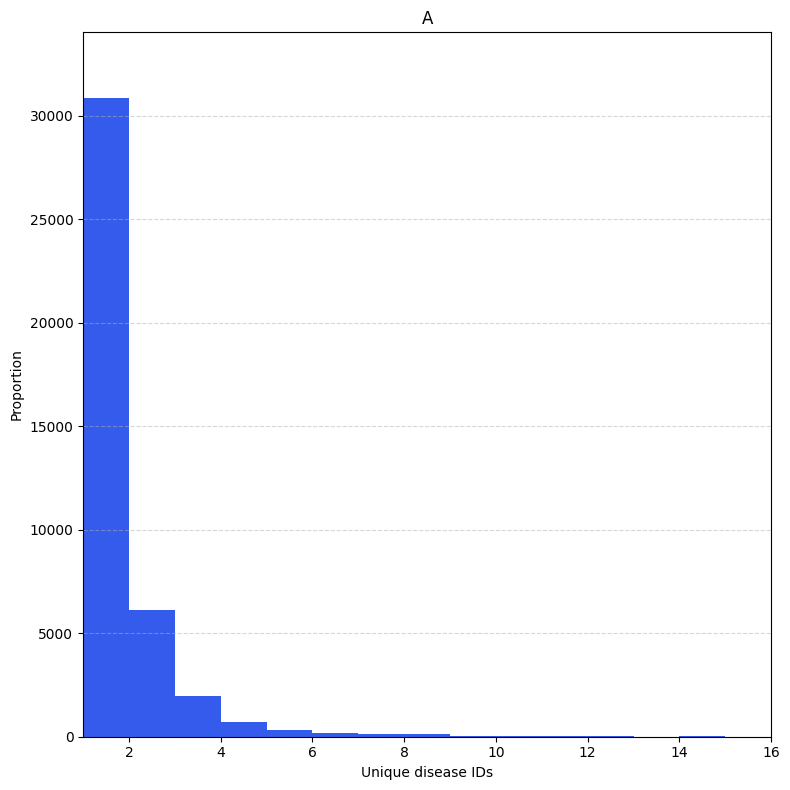

In [14]:
plt.figure(figsize=(8, 8))
data = variant_pd[variant_pd["uniqueDiseases"] <= 15]["uniqueDiseases"]
bins = range(int(data.min()), int(data.max()) + 2)
n, bins, patches = plt.hist(
    data,
    bins=bins,
    color="#345BEB",
)
plt.title("A")
plt.xlabel("Unique disease IDs")
plt.ylabel("Proportion")
plt.gca().set_ylim(0, plt.gca().get_ylim()[1] * 1.05)
plt.gca().set_xlim(bins[0], bins[-1])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [15]:
print("Number with more than one:", len(variant_pd[variant_pd["uniqueDiseases"] > 1]))
print(
    "Percentage with more than 1:",
    len(variant_pd[variant_pd["uniqueDiseases"] > 1]) / len(variant_pd),
)
print("Mean:", variant_pd["uniqueDiseases"].mean())
print("Median:", variant_pd["uniqueDiseases"].median())
print("Max:", variant_pd["uniqueDiseases"].max())
print("Standard Deviation:", variant_pd["uniqueDiseases"].std())


Number with more than one: 9828
Percentage with more than 1: 0.24143860855893481
Mean: 1.4796098855205622
Median: 1.0
Max: 85
Standard Deviation: 1.5444252603214186


# Unique Therapeutic Areas


Univariate regression results:
                     covariate  coefficient  std_error       p_value
0                   maxAbsBeta     0.064798   0.003842  8.220475e-64
1  maxCoefficientDetermination     0.039349   0.002822  3.460952e-44
2                       maxMAF     0.017104   0.004542  1.662870e-04
3       maxEffectiveSampleSize     0.070287   0.004667  2.974352e-51
4        yearsSincePublication     0.073705   0.004238  9.344674e-68
5               gerpNormalised     0.020167   0.004482  6.822045e-06
6                    vepBinary     0.045973   0.003944  2.163465e-31
Multiple regression results:
                     covariate  coefficient  std_error        p_value
0                   maxAbsBeta     0.085525   0.004841   7.389724e-70
1  maxCoefficientDetermination     0.013393   0.003560   1.685653e-04
2                       maxMAF     0.036837   0.004910   6.283400e-14
3       maxEffectiveSampleSize     0.125595   0.004955  9.240653e-142
4        yearsSincePublication     0.0

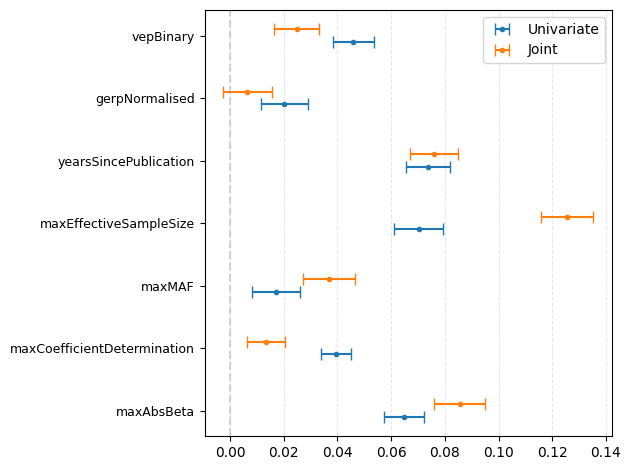

In [16]:
df = variant_pd[
    [
        "uniqueTherapeuticAreas",
        "maxAbsBeta",
        "maxCoefficientDetermination",
        "maxMAF",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
        "gerpNormalised",
        "vepScore",
    ]
].copy()

# Handle missing values
df["gerpNormalised"] = df["gerpNormalised"].fillna(df["gerpNormalised"].mean())
df["maxAbsBeta"] = df["maxAbsBeta"].fillna(df["maxAbsBeta"].mean())

df["vepBinary"] = (df["vepScore"] >= 0.66).astype(int)
df["yearsSincePublication"] = 2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year
df["yearsSincePublication"] = df["yearsSincePublication"].fillna(df["yearsSincePublication"].mean())

# Standardize covariates
for col in [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
    "maxEffectiveSampleSize",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        # Add small epsilon to avoid log(0) if necessary, though check showed no 0s
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        df[col] = (df[col] - df[col].mean()) / df[col].std()


covariates_univariate = [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
]
covariates_multi = [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueTherapeuticAreas"]
    model_uni = sm.Poisson(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueTherapeuticAreas"]
model_multi = sm.Poisson(y_multi, x_multi).fit(disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
# ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
print(np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2)


0.12944034965344842


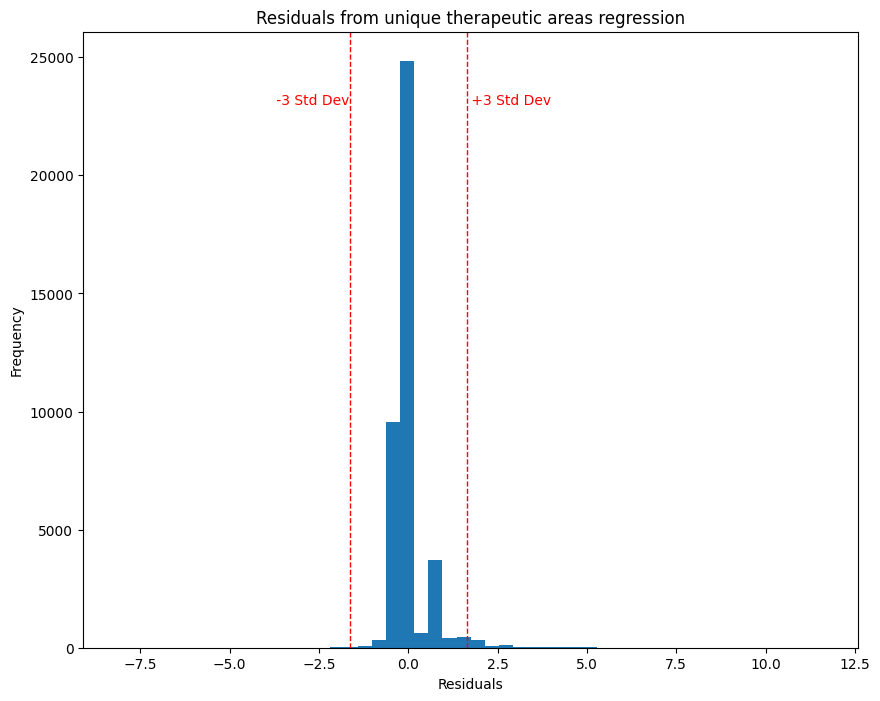

In [18]:
residuals_multi = model_multi.resid_response
std_dev_residuals = np.std(residuals_multi)

plt.figure(figsize=(10, 8))
plt.hist(residuals_multi, bins=50)
plt.title("Residuals from unique therapeutic areas regression")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Add vertical lines for standard deviations
plt.axvline(float(3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)
plt.axvline(float(-3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)

# Add text annotations for the lines
y_lim = plt.ylim()
plt.text(
    float(3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " +3 Std Dev",
    color="r",
    verticalalignment="top",
)
plt.text(
    float(-3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " -3 Std Dev",
    color="r",
    horizontalalignment="right",
    verticalalignment="top",
)

plt.show()


# Unique Diseases full model


Univariate regression results:
                     covariate  coefficient  std_error        p_value
0                   maxAbsBeta     0.146520   0.003083   0.000000e+00
1  maxCoefficientDetermination     0.097125   0.003029  1.475793e-225
2                       maxMAF     0.019687   0.004274   4.098300e-06
3       maxEffectiveSampleSize     0.146594   0.004497  4.388041e-233
4        yearsSincePublication     0.184366   0.003648   0.000000e+00
5               gerpNormalised     0.053024   0.004140   1.465634e-37
6                    vepBinary     0.095145   0.003303  2.038712e-182
Multiple regression results:
                     covariate  coefficient  std_error       p_value
0                   maxAbsBeta     0.164949   0.003760  0.000000e+00
1  maxCoefficientDetermination     0.011742   0.002928  6.072817e-05
2                       maxMAF     0.059708   0.004492  2.600818e-40
3       maxEffectiveSampleSize     0.254653   0.004481  0.000000e+00
4        yearsSincePublication     

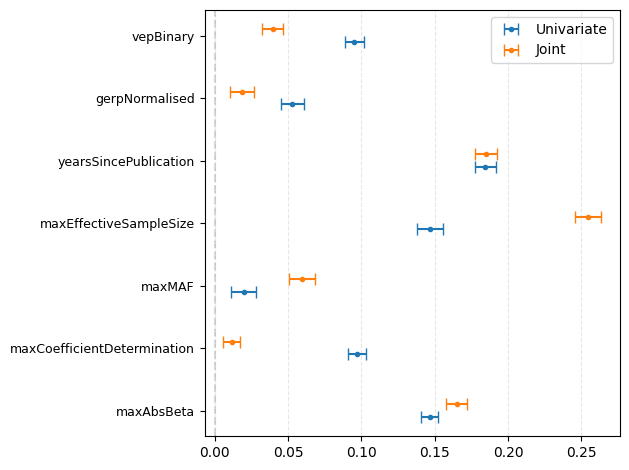

In [19]:
df = variant_pd[
    [
        "uniqueDiseases",
        "maxAbsBeta",
        "maxCoefficientDetermination",
        "maxMAF",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
        "gerpNormalised",
        "vepScore",
    ]
].copy()
df["maxAbsBeta"] = df["maxAbsBeta"].fillna(df["maxAbsBeta"].mean())
df["gerpNormalised"] = df["gerpNormalised"].fillna(df["gerpNormalised"].mean())
df["vepBinary"] = (df["vepScore"] >= 0.66).astype(int)
df["yearsSincePublication"] = 2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year
df["yearsSincePublication"] = df["yearsSincePublication"].fillna(df["yearsSincePublication"].mean())

# Standardize covariates
for col in [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
    "maxEffectiveSampleSize",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        if df[col].std() > 0:
            df[col] = (df[col] - df[col].mean()) / df[col].std()
        else:
            df[col] = 0


covariates_univariate = [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
]
covariates_multi = [
    "maxAbsBeta",
    "maxCoefficientDetermination",
    "maxMAF",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "gerpNormalised",
    "vepBinary",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueDiseases"]
    model_uni = sm.NegativeBinomial(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueDiseases"]
model_multi = sm.NegativeBinomial(y_multi, x_multi).fit(disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
# ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
print(np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2)


0.2005453982051004


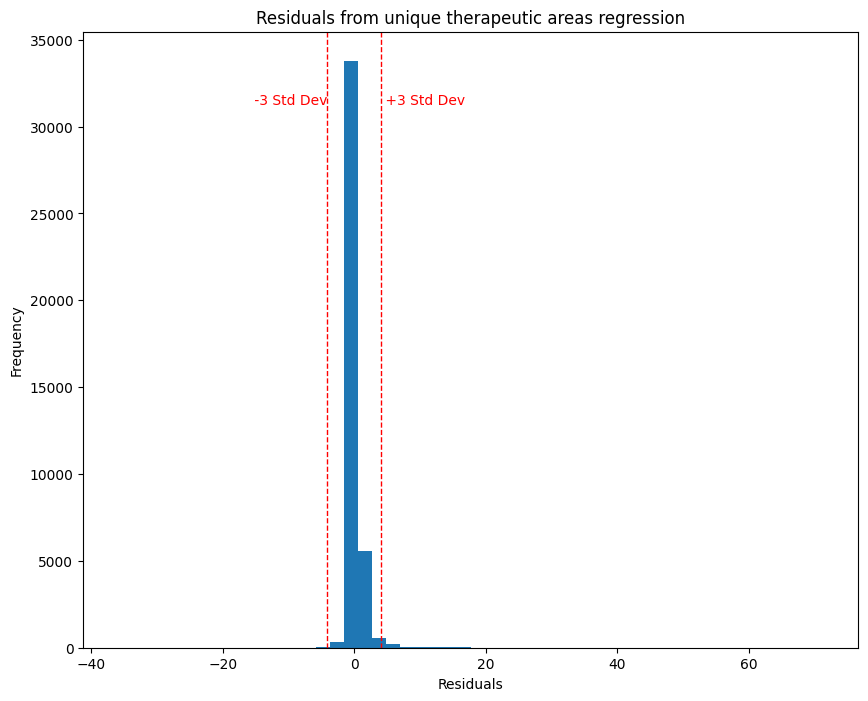

In [21]:
residuals_multi = model_multi.resid_response
std_dev_residuals = np.std(residuals_multi)

plt.figure(figsize=(10, 8))
plt.hist(residuals_multi, bins=50)
plt.title("Residuals from unique therapeutic areas regression")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Add vertical lines for standard deviations
plt.axvline(float(3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)
plt.axvline(float(-3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)

# Add text annotations for the lines
y_lim = plt.ylim()
plt.text(
    float(3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " +3 Std Dev",
    color="r",
    verticalalignment="top",
)
plt.text(
    float(-3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " -3 Std Dev",
    color="r",
    horizontalalignment="right",
    verticalalignment="top",
)

plt.show()


# Unique diseases biological factors


Univariate regression results:
        covariate  coefficient  std_error        p_value
0      maxAbsBeta     0.146520   0.003083   0.000000e+00
1          maxMAF     0.019687   0.004274   4.098300e-06
2  gerpNormalised     0.053024   0.004140   1.465634e-37
3       vepBinary     0.095145   0.003303  2.038712e-182
Multiple regression results:
        covariate  coefficient  std_error        p_value
0      maxAbsBeta     0.155047   0.003323   0.000000e+00
1          maxMAF     0.094936   0.004457  1.140872e-100
2  gerpNormalised     0.023735   0.004280   2.921000e-08
3       vepBinary     0.064992   0.003557   1.417207e-74
Pseudo R-squared: 0.023035647114646896


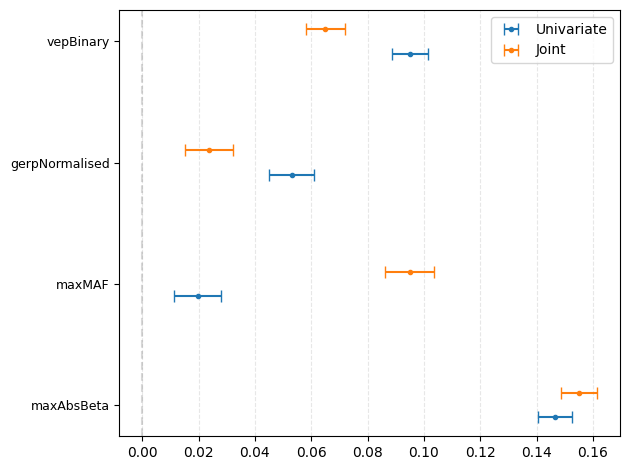

In [22]:
df = variant_pd[
    [
        "uniqueDiseases",
        "maxAbsBeta",
        "maxMAF",
        "gerpNormalised",
        "vepScore",
    ]
].copy()
df["maxAbsBeta"] = df["maxAbsBeta"].fillna(df["maxAbsBeta"].mean())
df["gerpNormalised"] = df["gerpNormalised"].fillna(df["gerpNormalised"].mean())
df["vepBinary"] = (df["vepScore"] >= 0.66).astype(int)

# Standardize covariates
for col in [
    "maxAbsBeta",
    "maxMAF",
    "gerpNormalised",
    "vepBinary",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        if df[col].std() > 0:
            df[col] = (df[col] - df[col].mean()) / df[col].std()
        else:
            df[col] = 0


covariates_univariate = [
    "maxAbsBeta",
    "maxMAF",
    "gerpNormalised",
    "vepBinary",
]
covariates_multi = [
    "maxAbsBeta",
    "maxMAF",
    "gerpNormalised",
    "vepBinary",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueDiseases"]
    model_uni = sm.NegativeBinomial(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueDiseases"]
model_multi = sm.NegativeBinomial(y_multi, x_multi).fit(disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
# ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
print(np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2)


0.056081343372000304


# Unique diseases statistical factors


Univariate regression results:
                     covariate  coefficient  std_error        p_value
0  maxCoefficientDetermination     0.097125   0.003029  1.475793e-225
1       maxEffectiveSampleSize     0.146594   0.004497  4.388041e-233
2        yearsSincePublication     0.184366   0.003648   0.000000e+00
Multiple regression results:
                     covariate  coefficient  std_error        p_value
0  maxCoefficientDetermination     0.087350   0.003175  1.413835e-166
1       maxEffectiveSampleSize     0.228084   0.004492   0.000000e+00
2        yearsSincePublication     0.205590   0.003909   0.000000e+00
Pseudo R-squared: 0.045557904577051445


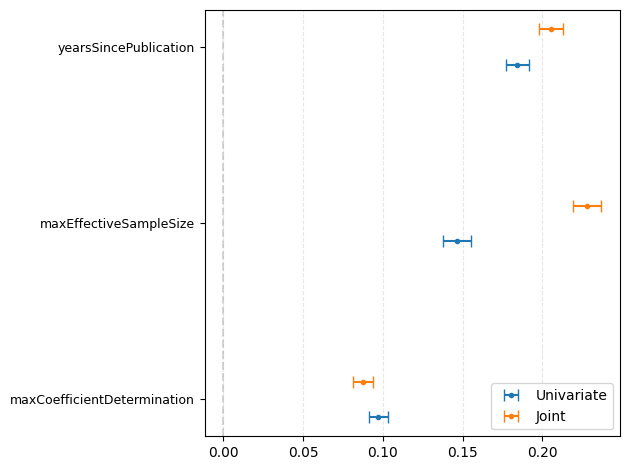

In [24]:
df = variant_pd[
    [
        "uniqueDiseases",
        "maxCoefficientDetermination",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
    ]
].copy()
df["yearsSincePublication"] = 2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year
df["yearsSincePublication"] = df["yearsSincePublication"].fillna(df["yearsSincePublication"].mean())

# Standardize covariates
for col in [
    "maxCoefficientDetermination",
    "yearsSincePublication",
    "maxEffectiveSampleSize",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        if df[col].std() > 0:
            df[col] = (df[col] - df[col].mean()) / df[col].std()
        else:
            df[col] = 0


covariates_univariate = [
    "maxCoefficientDetermination",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
]
covariates_multi = [
    "maxCoefficientDetermination",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueDiseases"]
    model_uni = sm.NegativeBinomial(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueDiseases"]
model_multi = sm.NegativeBinomial(y_multi, x_multi).fit(disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
# ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
print(np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2)


0.0073667490583199545


# Discordance analysis


In [26]:
pleiotropic_discordant_variants = (
    variant_pleiotropy.filter(f.col("betaSignConcordance") <= 0.8)
    .filter(f.col("uniqueDiseases") >= 10)
    .sort(f.desc("uniqueDiseases"))
)


In [27]:
(
    pleiotropic_discordant_variants.select(
        "variantId",
        "betaSignConcordance",
        "uniqueDiseases",
        "uniqueTherapeuticAreas",
        "uniqueDiseaseNames",
        "uniqueTherapeuticAreaNames",
        "prioritisedGenes",
    ).write.parquet(
        f"{output_path}/pleiotropic_discordant_variants",
        mode="overwrite",
    )
)


In [28]:
# Create a dataframe with disease and therapeutic area information
disease_df = session.spark.read.parquet(f"{release_path}/disease/disease.parquet").select(f.col("id"), f.col("name"))

# Create a mapping from diseaseId to diseaseName
disease_id_to_name = (
    studies.withColumn("exploded_disease_id", f.explode("diseaseIds"))
    .join(
        disease_df.alias("d"),
        f.col("exploded_disease_id") == f.col("d.id"),
        "left",
    )
    .groupBy("studyId")
    .agg(f.collect_list("name").alias("diseaseNames"))
)

# Create a mapping from therapeuticAreaId to therapeuticAreaName
ta_id_to_name = (
    studies.withColumn("exploded_ta_id", f.explode("mappedTherapeuticAreas"))
    .join(
        disease_df.alias("t"),
        f.col("exploded_ta_id") == f.col("t.id"),
        "left",
    )
    .withColumn(
        "ta_name",
        f.when(f.col("exploded_ta_id") == "other", f.lit("other")).otherwise(f.col("t.name")),
    )
    .groupBy("studyId")
    .agg(f.collect_list("ta_name").alias("therapeuticAreaNames"))
)

# Join the new columns back to the studies dataframe
studies_with_names = studies.join(disease_id_to_name, "studyId", "left").join(ta_id_to_name, "studyId", "left")

# Show the result
studies_with_names.select(
    "studyId",
    "diseaseIds",
    "diseaseNames",
    "mappedTherapeuticAreas",
    "therapeuticAreaNames",
).show(truncate=False)


+--------------------------------------+---------------------------------------+---------------------------------------------------------------+----------------------------------+--------------------------------------------------------------------+
|studyId                               |diseaseIds                             |diseaseNames                                                   |mappedTherapeuticAreas            |therapeuticAreaNames                                                |
+--------------------------------------+---------------------------------------+---------------------------------------------------------------+----------------------------------+--------------------------------------------------------------------+
|FINNGEN_R12_AUTOIMMUNE_HYPERTHYROIDISM|[EFO_0004237]                          |[Graves disease]                                               |[EFO_0000540]                     |[immune system disease]                                             |
|FIN

In [29]:
df_for_plot = (
    qualified_cs.join(
        studies_with_names.select(
            "studyId",
            "diseaseNames",
            "mappedTherapeuticAreas",
            "therapeuticAreaNames",
        ),
        "studyId",
        "left",
    )
    .filter(f.col("variantId") == "19_44908684_T_C")
    .filter(f.col("originalBeta").isNotNull())
    .select(
        "studyId",
        "diseaseIds",
        "diseaseNames",
        "mappedTherapeuticAreas",
        "therapeuticAreaNames",
        "rescaledStatistics.absZScore",
        "rescaledStatistics.minorAlleleEstimatedBeta",
        "rescaledStatistics.estimatedSE",
        "variantStatistics.pValueMantissa",
        "variantStatistics.pValueExponent",
    )
    .sort("pValueExponent")
    .show()
)


+--------------------+---------------+--------------------+----------------------+--------------------+------------------+------------------------+--------------------+--------------+--------------+
|             studyId|     diseaseIds|        diseaseNames|mappedTherapeuticAreas|therapeuticAreaNames|         absZScore|minorAlleleEstimatedBeta|         estimatedSE|pValueMantissa|pValueExponent|
+--------------------+---------------+--------------------+----------------------+--------------------+------------------+------------------------+--------------------+--------------+--------------+
|        GCST90480731|[MONDO_0004975]| [Alzheimer disease]|         [EFO_0000618]|[nervous system d...| 38.45960218202991|      0.9899354319983616| 0.02573961704837667|           1.0|          -323|
|FINNGEN_R12_KRA_P...|   [HP_0000726]|          [Dementia]|               [other]|             [other]| 37.53138248632944|      0.4766303484349317|0.012699514828917936|         2.225|          -308|
|FINN

/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_85469/2380989842.py:35: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



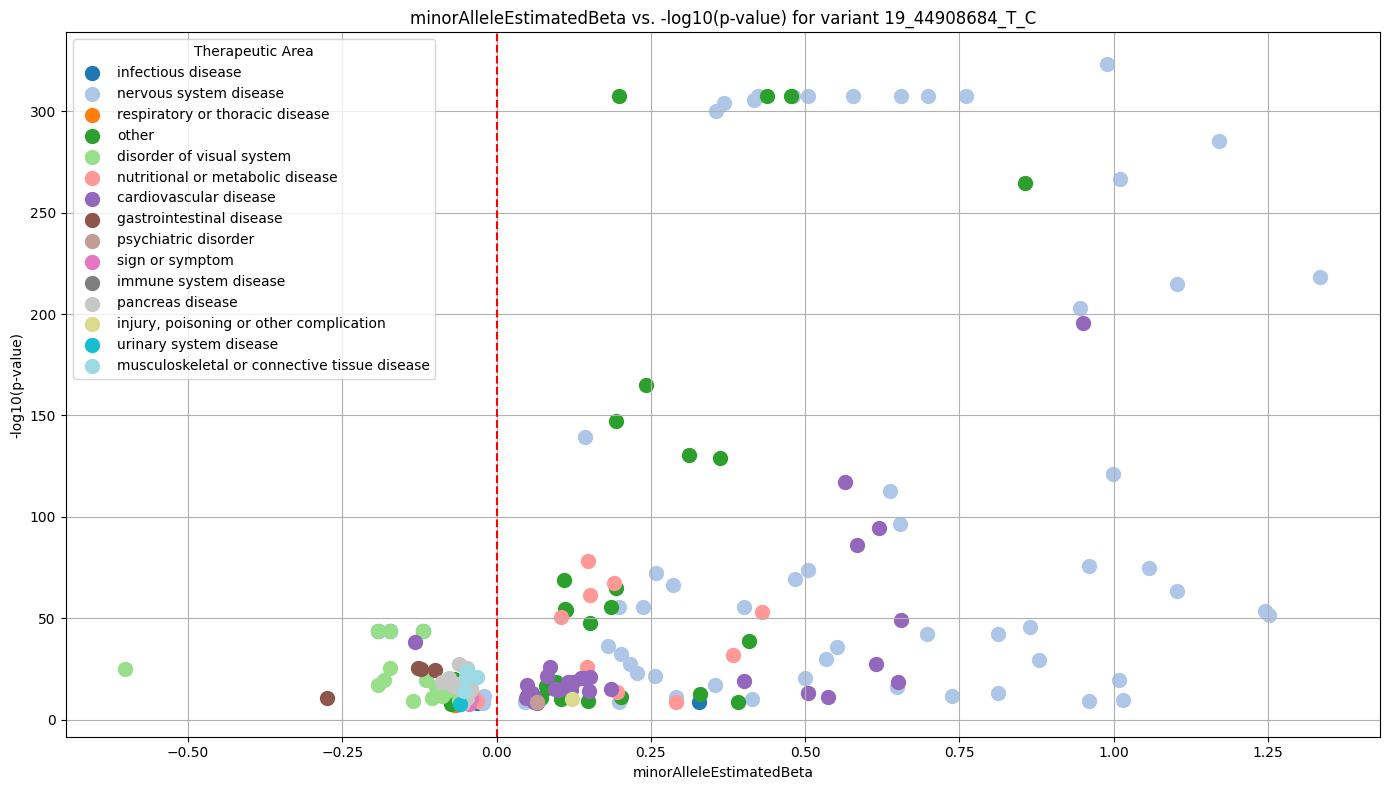

In [30]:
df_for_plot = (
    qualified_cs.filter(f.col("variantId") == "19_44908684_T_C")
    .filter(f.col("originalBeta").isNotNull())
    .join(
        studies_with_names.select(
            "studyId",
            "diseaseNames",
            "mappedTherapeuticAreas",
            "therapeuticAreaNames",
        ),
        "studyId",
        "left",
    )
    .select(
        "studyId",
        "diseaseIds",
        "diseaseNames",
        "mappedTherapeuticAreas",
        "therapeuticAreaNames",
        "rescaledStatistics.minorAlleleEstimatedBeta",
        "variantStatistics.pValueMantissa",
        "variantStatistics.pValueExponent",
    )
    .toPandas()
)

df_for_plot["neg_log10_p"] = -(np.log10(df_for_plot["pValueMantissa"]) + df_for_plot["pValueExponent"])

# Explode the mappedTherapeuticAreas column to have one row per therapeutic area
df_for_plot_exploded = df_for_plot.explode("therapeuticAreaNames")

# Create a color map for therapeutic areas
unique_tas = df_for_plot_exploded["therapeuticAreaNames"].unique()
# Using a colormap with enough distinct colors
colors = plt.cm.get_cmap("tab20", len(unique_tas))
ta_color_map = {ta: colors(i) for i, ta in enumerate(unique_tas)}

plt.figure(figsize=(14, 8))

# Plot each therapeutic area with a different color
for ta, color in ta_color_map.items():
    subset = df_for_plot_exploded[df_for_plot_exploded["therapeuticAreaNames"] == ta]
    plt.scatter(subset["minorAlleleEstimatedBeta"], subset["neg_log10_p"], label=ta, color=color, s=100)

plt.xlabel("minorAlleleEstimatedBeta")
plt.ylabel("-log10(p-value)")
plt.title("minorAlleleEstimatedBeta vs. -log10(p-value) for variant 19_44908684_T_C")
plt.axvline(0, color="red", linestyle="--")
plt.grid(True)
plt.legend(title="Therapeutic Area", loc="upper left")
plt.tight_layout()
plt.show()


In [31]:
# Group by therapeutic area and calculate beta sign concordance
def beta_concordance_and_sign(betas):
    """Calculates the proportion of the most frequent sign and the sign itself."""
    positive_betas = (betas > 0).sum()
    negative_betas = (betas < 0).sum()
    total_betas = positive_betas + negative_betas

    if total_betas == 0:
        concordance = np.nan
        sign = "N/A"
    else:
        concordance = max(positive_betas, negative_betas) / total_betas
        if positive_betas > negative_betas:
            sign = "+"
        elif negative_betas > positive_betas:
            sign = "-"
        else:
            sign = "Equal"

    return pd.Series({"concordance": concordance, "dominant_sign": sign})


# Apply the function to each therapeutic area group
beta_concordance_by_ta = (
    df_for_plot_exploded.groupby("therapeuticAreaNames")
    .apply(
        lambda g: pd.Series(
            {
                **beta_concordance_and_sign(g["minorAlleleEstimatedBeta"]),
                "unique_studyIds": g["studyId"].nunique(),
            }
        )
    )
    .reset_index()
)


print("Beta sign concordance by therapeutic area:")
beta_concordance_by_ta


Beta sign concordance by therapeutic area:


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_85469/1743833550.py:26: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,therapeuticAreaNames,concordance,dominant_sign,unique_studyIds
0,cardiovascular disease,0.933333,+,30
1,disorder of visual system,1.000000,-,16
2,gastrointestinal disease,1.000000,-,6
3,immune system disease,1.000000,-,1
4,infectious disease,0.888889,-,9
5,"injury, poisoning or other complication",1.000000,+,1
6,musculoskeletal or connective tissue disease,1.000000,-,4
7,nervous system disease,0.933333,+,60
8,nutritional or metabolic disease,0.818182,+,11
9,other,0.843750,+,32


/var/folders/4l/52c74xkd7v38plbmqnhw2dz40000gq/T/ipykernel_85469/1347237687.py:35: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



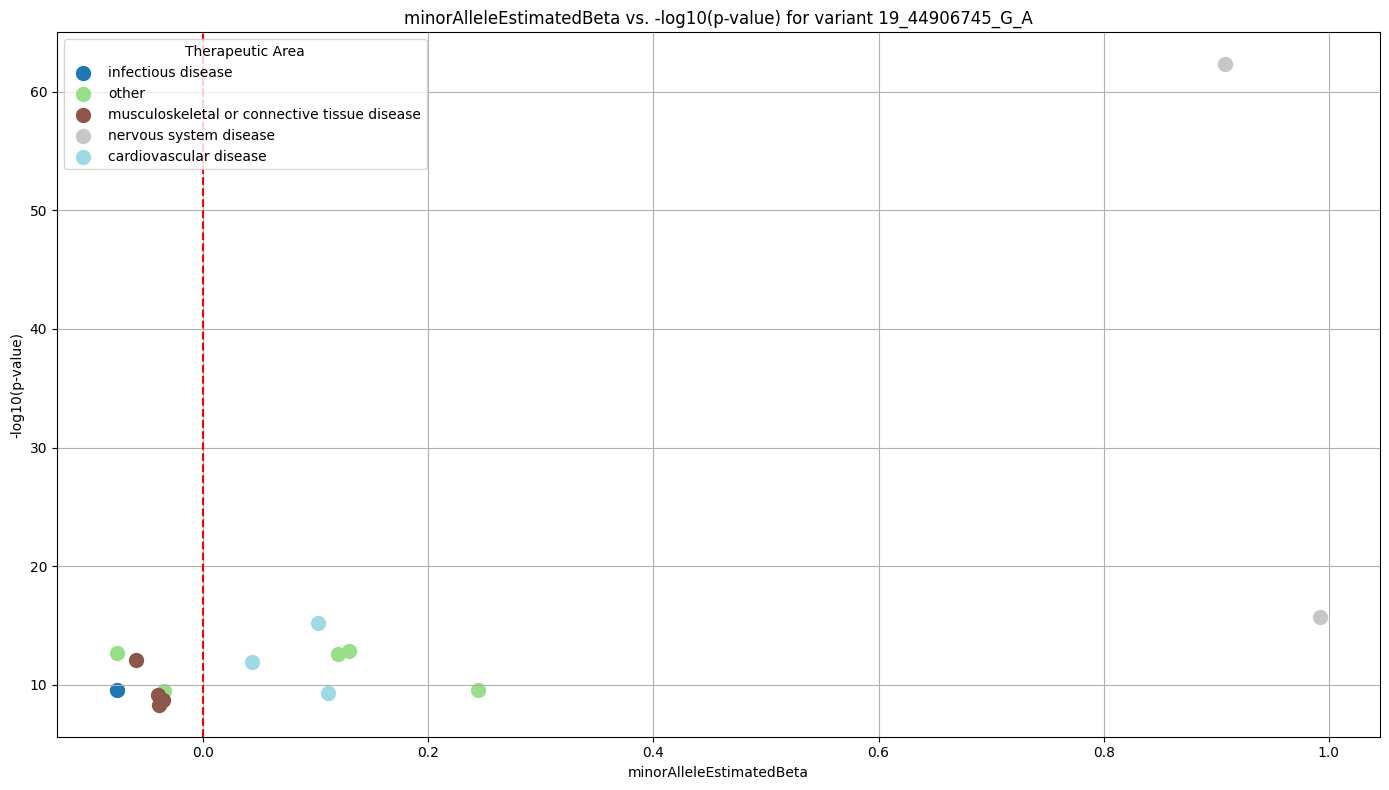

In [32]:
df_for_plot = (
    qualified_cs.filter(f.col("variantId") == "19_44906745_G_A")
    .filter(f.col("originalBeta").isNotNull())
    .join(
        studies_with_names.select(
            "studyId",
            "diseaseNames",
            "mappedTherapeuticAreas",
            "therapeuticAreaNames",
        ),
        "studyId",
        "left",
    )
    .select(
        "studyId",
        "diseaseIds",
        "diseaseNames",
        "mappedTherapeuticAreas",
        "therapeuticAreaNames",
        "rescaledStatistics.minorAlleleEstimatedBeta",
        "variantStatistics.pValueMantissa",
        "variantStatistics.pValueExponent",
    )
    .toPandas()
)

df_for_plot["neg_log10_p"] = -(np.log10(df_for_plot["pValueMantissa"]) + df_for_plot["pValueExponent"])

# Explode the mappedTherapeuticAreas column to have one row per therapeutic area
df_for_plot_exploded = df_for_plot.explode("therapeuticAreaNames")

# Create a color map for therapeutic areas
unique_tas = df_for_plot_exploded["therapeuticAreaNames"].unique()
# Using a colormap with enough distinct colors
colors = plt.cm.get_cmap("tab20", len(unique_tas))
ta_color_map = {ta: colors(i) for i, ta in enumerate(unique_tas)}

plt.figure(figsize=(14, 8))

# Plot each therapeutic area with a different color
for ta, color in ta_color_map.items():
    subset = df_for_plot_exploded[df_for_plot_exploded["therapeuticAreaNames"] == ta]
    plt.scatter(subset["minorAlleleEstimatedBeta"], subset["neg_log10_p"], label=ta, color=color, s=100)

plt.xlabel("minorAlleleEstimatedBeta")
plt.ylabel("-log10(p-value)")
plt.title("minorAlleleEstimatedBeta vs. -log10(p-value) for variant 19_44906745_G_A")
plt.axvline(0, color="red", linestyle="--")
plt.grid(True)
plt.legend(title="Therapeutic Area", loc="upper left")
plt.tight_layout()
plt.show()
